# Joint Environment–Schedule Fused-Wall Decoder v0

Executable notebook for the current SHA/Nexus fused-wall result.

Core wall:

$$F_r \equiv h_r + W_r \pmod{2^{32}}$$

Software addition erases operand identity. Hardware/environment can preserve operand orientation through carry-chain, routing, timing, power, EM, or VCD switching trace.

The decoder shape is:

$$F_r + \widehat{\Phi}_{E,r} + \Gamma_{schedule} + \text{state closure} \rightarrow (\widehat h_r,\widehat W_r)$$

This is a side-channel/shape-channel decoder scaffold, not a digest-only arbitrary preimage claim.

In [1]:
# Optional dependency bootstrap
# Safe to re-run. Installs only if a package is missing.
import sys, subprocess, importlib.util
for pkg in ["numpy", "pandas", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


In [2]:
# ============================================================
# Config
# ============================================================
RUN_RANDOM_SWEEP = True
RUN_BEAM_DEMO = True
RANDOM_SWEEP_TRIALS = 300
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
BEAM_TOPK_PER_ROUND = 8
BEAM_WIDTH = 128
BEAM_NOISE = 0.10
BEAM_MAX_ROUNDS = 64   # use 16/32 for faster debug
SEED = 1337

In [3]:
import hashlib, math, random, json
from dataclasses import dataclass
from typing import Dict, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MASK32 = 0xFFFFFFFF
random.seed(SEED); np.random.seed(SEED)

H0 = [0x6a09e667,0xbb67ae85,0x3c6ef372,0xa54ff53a,0x510e527f,0x9b05688c,0x1f83d9ab,0x5be0cd19]
K = [
0x428a2f98,0x71374491,0xb5c0fbcf,0xe9b5dba5,0x3956c25b,0x59f111f1,0x923f82a4,0xab1c5ed5,
0xd807aa98,0x12835b01,0x243185be,0x550c7dc3,0x72be5d74,0x80deb1fe,0x9bdc06a7,0xc19bf174,
0xe49b69c1,0xefbe4786,0x0fc19dc6,0x240ca1cc,0x2de92c6f,0x4a7484aa,0x5cb0a9dc,0x76f988da,
0x983e5152,0xa831c66d,0xb00327c8,0xbf597fc7,0xc6e00bf3,0xd5a79147,0x06ca6351,0x14292967,
0x27b70a85,0x2e1b2138,0x4d2c6dfc,0x53380d13,0x650a7354,0x766a0abb,0x81c2c92e,0x92722c85,
0xa2bfe8a1,0xa81a664b,0xc24b8b70,0xc76c51a3,0xd192e819,0xd6990624,0xf40e3585,0x106aa070,
0x19a4c116,0x1e376c08,0x2748774c,0x34b0bcb5,0x391c0cb3,0x4ed8aa4a,0x5b9cca4f,0x682e6ff3,
0x748f82ee,0x78a5636f,0x84c87814,0x8cc70208,0x90befffa,0xa4506ceb,0xbef9a3f7,0xc67178f2]

def rotr(x,n): return ((x>>n)|(x<<(32-n))) & MASK32
def shr(x,n): return x>>n
def Ch(x,y,z): return (x&y)^((~x&MASK32)&z)
def Maj(x,y,z): return (x&y)^(x&z)^(y&z)
def Sigma0(x): return rotr(x,2)^rotr(x,13)^rotr(x,22)
def Sigma1(x): return rotr(x,6)^rotr(x,11)^rotr(x,25)
def sigma0(x): return rotr(x,7)^rotr(x,18)^shr(x,3)
def sigma1(x): return rotr(x,17)^rotr(x,19)^shr(x,10)
def hw32(x): return int(x&MASK32).bit_count()
def bits_to_word(bits):
    out=0
    for j,b in enumerate(bits):
        if b: out|=(1<<j)
    return out&MASK32

## SHA-256 trace and local reverse closure

In [4]:
def sha256_pad_oneblock(msg: bytes)->bytes:
    ml=len(msg)*8; b=bytearray(msg); b.append(0x80)
    while len(b)%64 != 56: b.append(0)
    b += ml.to_bytes(8,'big')
    if len(b)!=64: raise ValueError(f'{len(msg)} bytes needs {len(b)//64} blocks; this notebook is one-block by default')
    return bytes(b)

def make_schedule(block: bytes):
    W=[int.from_bytes(block[4*i:4*i+4],'big') for i in range(16)]
    for t in range(16,64): W.append((sigma1(W[t-2])+W[t-7]+sigma0(W[t-15])+W[t-16])&MASK32)
    return W

def sha256_trace_oneblock(msg: bytes):
    block=sha256_pad_oneblock(msg); W=make_schedule(block)
    a,b,c,d,e,f,g,h=H0; states=[(a,b,c,d,e,f,g,h)]; T1s=[]; T2s=[]
    for r in range(64):
        T1=(h+Sigma1(e)+Ch(e,f,g)+K[r]+W[r])&MASK32
        T2=(Sigma0(a)+Maj(a,b,c))&MASK32
        h,g,f,e,d,c,b,a = g,f,e,(d+T1)&MASK32,c,b,a,(T1+T2)&MASK32
        T1s.append(T1); T2s.append(T2); states.append((a,b,c,d,e,f,g,h))
    internal64=states[-1]
    digest_words=[(internal64[i]+H0[i])&MASK32 for i in range(8)]
    digest=b''.join(w.to_bytes(4,'big') for w in digest_words).hex()
    return dict(msg=msg,block=block,W=W,states=states,T1=T1s,T2=T2s,internal64=internal64,digest=digest)

def restore_internal_from_digest_hex(digest_hex):
    words=[int(digest_hex[i:i+8],16) for i in range(0,64,8)]
    return tuple((words[i]-H0[i])&MASK32 for i in range(8))

def local_reverse_closure_from_next(x_next, r):
    a1,b1,c1,d1,e1,f1,g1,h1=x_next
    a,b,c,e,f,g = b1,c1,d1,f1,g1,h1
    T2=(Sigma0(a)+Maj(a,b,c))&MASK32
    T1=(a1-T2)&MASK32
    d=(e1-T1)&MASK32
    F=(T1-Sigma1(e)-Ch(e,f,g)-K[r])&MASK32
    return dict(a=a,b=b,c=c,d=d,e=e,f=f,g=g,T1=T1,T2=T2,F=F)

def reverse_step_with_W(x_next, W_r, r):
    p=local_reverse_closure_from_next(x_next,r); h=(p['F']-W_r)&MASK32
    return (p['a'],p['b'],p['c'],p['d'],p['e'],p['f'],p['g'],h)

DOS_HELLO=bytes.fromhex('b409ba0c01cd21b44ccd21'+'48656c6c6f2124'+'90'*37)
trace=sha256_trace_oneblock(DOS_HELLO)
print('len',len(DOS_HELLO),'digest',trace['digest'],'hashlib_match',hashlib.sha256(DOS_HELLO).hexdigest()==trace['digest'])
M=[int.from_bytes(trace['block'][4*i:4*i+4],'big') for i in range(16)]
print('M13,M14,M15:',[f'0x{x:08x}' for x in M[13:16]])
print('x64 restored:', restore_internal_from_digest_hex(trace['digest'])==trace['internal64'])

ok=True
for r in range(64):
    p=local_reverse_closure_from_next(trace['states'][r+1],r)
    if p['F'] != ((trace['states'][r][7]+trace['W'][r])&MASK32): ok=False
    if reverse_step_with_W(trace['states'][r+1], trace['W'][r], r) != trace['states'][r]: ok=False
print('Exact reverse closure validates:', ok)

len 55 digest e079e052b115f0bd7a1f7e4b76b896ecff094435418389aec7c54e26929a3b27 hashlib_match True
M13,M14,M15: ['0x90909080', '0x00000000', '0x000001b8']
x64 restored: True
Exact reverse closure validates: True


## Fused-wall exact decoder: $F+C+O ightarrow (h,W)$

In [5]:
def adder_trace_operands(h,W):
    h&=MASK32; W&=MASK32; F=(h+W)&MASK32; c=[0]*33; O={}; cls=[]
    for j in range(32):
        hj=(h>>j)&1; wj=(W>>j)&1; total=hj+wj+c[j]
        c[j+1]=1 if total>=2 else 0
        if hj==0 and wj==0: cls.append('K')
        elif hj==1 and wj==1: cls.append('G')
        else:
            cls.append('P'); O[j]=0 if (hj,wj)==(1,0) else 1
        assert ((F>>j)&1)==(total&1)
    return F,c,O,cls

def reconstruct_from_F_C_O(F,c,O):
    hb=[0]*32; wb=[0]*32
    for j in range(32):
        p=((F>>j)&1)^c[j]
        if p==0: hb[j]=wb[j]=c[j+1]
        else:
            if O[j]==0: hb[j]=1; wb[j]=0
            else: hb[j]=0; wb[j]=1
    return bits_to_word(hb),bits_to_word(wb)

ok=True; props=[]
for _ in range(1000):
    h=random.getrandbits(32); W=random.getrandbits(32)
    F,c,O,cls=adder_trace_operands(h,W); hh,WW=reconstruct_from_F_C_O(F,c,O)
    props.append(len(O)); ok &= (hh==h and WW==W)
print('Exact F+C+O theorem passes:',ok,'mean propagate bits',np.mean(props),'min/max',min(props),max(props))

Exact F+C+O theorem passes: True mean propagate bits 15.929 min/max 8 24


## Simulated environment bus and N-best candidates

,noise,h_bit_acc,W_bit_acc,pair_exact
0,0.00,1.000000,1.000000,1.000000
1,0.05,0.975521,0.975521,0.483333
2,0.10,0.949167,0.949167,0.206667
3,0.15,0.921771,0.921771,0.050000
4,0.20,0.901042,0.901042,0.030000
5,0.25,0.871250,0.871250,0.013333
6,0.30,0.856458,0.856458,0.003333
7,0.35,0.827292,0.827292,0.003333
8,0.40,0.796250,0.796250,0.000000


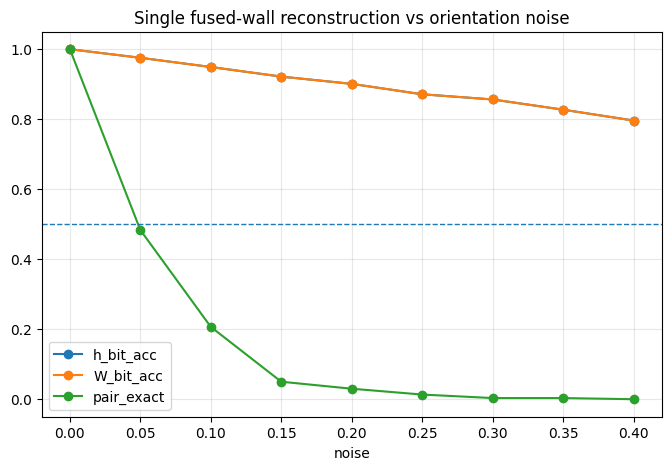

In [6]:
@dataclass
class Leak:
    F_true:int; carries:List[int]; measured_orientation:Dict[int,int]; reliability:float; true_orientation:Dict[int,int]
@dataclass(order=True)
class Candidate:
    cost:float; h:int; W:int; orientations:dict; carries:list; prop_count:int

def make_leak_for_round(h,W,noise,rng=random):
    F,c,O,cls=adder_trace_operands(h,W); measured={}
    for j,o in O.items(): measured[j]=(1-o) if rng.random()<noise else o
    return Leak(F,c,measured,max(0.51,1-noise),O)

def nbest_orientations_from_leak(F, leak, topk=8):
    opts=[]
    for j,meas in sorted(leak.measured_orientation.items()):
        p=max(min(leak.reliability,1-1e-12),1e-12); q=1-p
        opts.append((j, -math.log(p if meas==0 else q), -math.log(q if meas==0 else p)))
    base={}; base_cost=0; flips=[]
    for j,c0,c1 in opts:
        if c0<=c1: base[j]=0; base_cost+=c0; flips.append((c1-c0,j))
        else: base[j]=1; base_cost+=c1; flips.append((c0-c1,j))
    flips.sort(); m=min(14,len(flips)); raw=[]
    for mask in range(1<<m):
        O=dict(base); cost=base_cost
        for k,(delta,j) in enumerate(flips[:m]):
            if (mask>>k)&1: O[j]=1-O[j]; cost+=delta
        raw.append((cost,O))
    raw.sort(key=lambda x:x[0]); out=[]
    for cost,O in raw[:topk]:
        h,W=reconstruct_from_F_C_O(F,leak.carries,O)
        out.append(Candidate(cost,h,W,O,leak.carries,len(O)))
    return out

def single_wall_noise_sweep(trials=300, noise_levels=NOISE_LEVELS):
    rows=[]
    for noise in noise_levels:
        hc=wc=tot=exact=0
        for _ in range(trials):
            h=random.getrandbits(32); W=random.getrandbits(32)
            leak=make_leak_for_round(h,W,noise); cand=nbest_orientations_from_leak(leak.F_true,leak,1)[0]
            hc+=32-hw32(cand.h^h); wc+=32-hw32(cand.W^W); tot+=32; exact += int(cand.h==h and cand.W==W)
        rows.append(dict(noise=noise,h_bit_acc=hc/tot,W_bit_acc=wc/tot,pair_exact=exact/trials))
    return pd.DataFrame(rows)

if RUN_RANDOM_SWEEP:
    sweep_df=single_wall_noise_sweep(RANDOM_SWEEP_TRIALS)
    display(sweep_df)
    ax=sweep_df.plot(x='noise',y=['h_bit_acc','W_bit_acc','pair_exact'],marker='o',figsize=(8,5))
    ax.axhline(.5,ls='--',lw=1); ax.set_title('Single fused-wall reconstruction vs orientation noise'); ax.grid(alpha=.3); plt.show()

## Schedule legality and joint reverse beam

In [7]:
def schedule_pred(Wd,t): return (sigma1(Wd[t-2])+Wd[t-7]+sigma0(Wd[t-15])+Wd[t-16])&MASK32
def schedule_factor_ready(Wd,t): return all(k in Wd for k in (t,t-2,t-7,t-15,t-16))
def schedule_residual_hw(Wd,t): return hw32(Wd[t]^schedule_pred(Wd,t))
Wtrue={i:trace['W'][i] for i in range(64)}
print('true schedule residual sum',sum(schedule_residual_hw(Wtrue,t) for t in range(16,64)))

@dataclass
class BeamNode:
    state:Tuple[int,...]; W:Dict[int,int]; score:float; scored_factors:frozenset; path:Tuple[Tuple[int,int,float],...]

def factors_newly_closed(Wd,scored):
    return [t for t in range(16,64) if t not in scored and schedule_factor_ready(Wd,t)]

def make_round_leaks_from_trace(tr,noise):
    return [make_leak_for_round(tr['states'][r][7],tr['W'][r],noise) for r in range(64)]

def joint_beam_decode(tr,noise=.1,topk=8,beam_width=128,max_rounds=64,lambda_schedule=2.0):
    x64=restore_internal_from_digest_hex(tr['digest']); leaks=make_round_leaks_from_trace(tr,noise); trueW=tr['W']
    beam=[BeamNode(x64,{},0.0,frozenset(),tuple())]; hist=[]
    for step,r in enumerate(list(reversed(range(64)))[:max_rounds],1):
        new=[]
        for node in beam:
            F=local_reverse_closure_from_next(node.state,r)['F']
            for cand in nbest_orientations_from_leak(F,leaks[r],topk):
                prev=reverse_step_with_W(node.state,cand.W,r); Wd=dict(node.W); Wd[r]=cand.W
                score=node.score+cand.cost; scored=set(node.scored_factors)
                for t in factors_newly_closed(Wd,node.scored_factors):
                    score += lambda_schedule*schedule_residual_hw(Wd,t); scored.add(t)
                new.append(BeamNode(prev,Wd,score,frozenset(scored),node.path+((r,cand.W,cand.cost),)))
        new.sort(key=lambda n:n.score); beam=new[:beam_width]; best=beam[0]
        keys=sorted(best.W); word_acc=float(np.mean([best.W[k]==trueW[k] for k in keys])) if keys else 0
        bit_err=sum(hw32(best.W[k]^trueW[k]) for k in keys)
        true_in=any(all(n.W[k]==trueW[k] for k in n.W) for n in beam)
        hist.append(dict(step=step,round=r,beam_size=len(beam),best_score=best.score,best_known_word_acc=word_acc,best_total_hw_error=bit_err,true_partial_path_in_beam=true_in,closed_schedule_factors_best=len(best.scored_factors)))
    return beam,pd.DataFrame(hist)

if RUN_BEAM_DEMO:
    beam,beam_hist=joint_beam_decode(trace,BEAM_NOISE,BEAM_TOPK_PER_ROUND,BEAM_WIDTH,BEAM_MAX_ROUNDS,2.0)
    display(beam_hist.tail(10))
    best=beam[0]; keys=sorted(best.W); trueW=trace['W']
    print('decoded rounds',len(keys),'word_acc',np.mean([best.W[k]==trueW[k] for k in keys]),'bit_acc',1-sum(hw32(best.W[k]^trueW[k]) for k in keys)/(32*len(keys)),'closed_factors',len(best.scored_factors),'score',best.score)
    ax=beam_hist.plot(x='step',y=['best_known_word_acc','true_partial_path_in_beam'],marker='o',figsize=(8,5)); ax.set_ylim(-.05,1.05); ax.grid(alpha=.3); plt.show()

true schedule residual sum 0


KeyError: 28

## Export outputs

In [ ]:
results={'digest':trace['digest'],'message_len':len(DOS_HELLO),'M13_M14_M15':[f'0x{x:08x}' for x in M[13:16]]}
if 'sweep_df' in globals():
    p='/mnt/data/joint_fused_wall_noise_sweep.csv'; sweep_df.to_csv(p,index=False); results['noise_sweep_csv']=p
if 'beam_hist' in globals():
    p='/mnt/data/joint_fused_wall_beam_history.csv'; beam_hist.to_csv(p,index=False); results['beam_history_csv']=p
p='/mnt/data/joint_fused_wall_decoder_summary.json'
with open(p,'w') as f: json.dump(results,f,indent=2)
print(json.dumps(results,indent=2))